Notebook 5 — Self-Similarity and MEV on Real Contexts

Pipeline:

SemCor
   ↓

56 occurrences of "bank"
   ↓

BERT hidden states
   ↓

Self-Similarity
   ↓
   
MEV

cell 1 - imports

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append("..")
from src.extraction import load_contexts
from src.embeddings import get_word_embedding
from src.similarity import average_similarity
from src.mev import compute_mev
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


cell 2 - verify contexts

In [2]:
bank_contexts = load_contexts(
    "../data/bank_contexts.json"
)

print(
    "Number of contexts:",
    len(bank_contexts)
)

Number of contexts: 56


cell 3 - load bert

In [13]:
from transformers import AutoTokenizer
from transformers import AutoModel

tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

model = AutoModel.from_pretrained(
    "bert-base-uncased",
    output_hidden_states=True
)

model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dropout(p=

cell 3 - extract Embeddings

In [ ]:
all_embeddings = []

for context in bank_contexts:

    embeddings = get_word_embedding(
        context,
        "bank",
        tokenizer,
        model
    )

    if embeddings is not None:

        all_embeddings.append(
            embeddings
        )

print(
    "Valid contexts:",
    len(all_embeddings)
)

It permits the state to take over bank accounts , stocks and other personal property of persons missing for seven years or more .
Position: 8
Token: bank

Dewey Lawrence , a Tyler lawyer representing the Texas Bankers Association , sounded the opposition keynote when he said it would force banks to violate their contractual obligations with depositors and undermine the confidence of bank customers .
Position: 37
Token: bank

To be eligible to borrow from a Bank for Cooperatives , a cooperative must be an association in which farmers act together in processing and marketing farm products , purchasing farm supplies , or furnishing farm business services , and must meet the requirements set forth in the Farm Credit Act of 1933 , as amended .
Position: 8
Token: bank

Interest rates are determined by the board of directors of the bank with the approval of the Farm Credit Administration .
Position: 12
Token: bank

For further information , contact the Bank for Cooperatives serving the region

cell 4 - Verify shapes

In [4]:
print(
    len(all_embeddings[0])
)

13


cell 5 - Compute Self-Similarity

In [5]:
bank_similarity = []

num_layers = len(
    all_embeddings[0]
)

for layer_idx in range(
    num_layers
):

    layer_vectors = []

    for sentence_idx in range(
        len(all_embeddings)
    ):

        layer_vectors.append(
            all_embeddings[sentence_idx][layer_idx]
        )

    score = average_similarity(
        layer_vectors
    )

    bank_similarity.append(score)

cell 6 - Plot self-Similarity

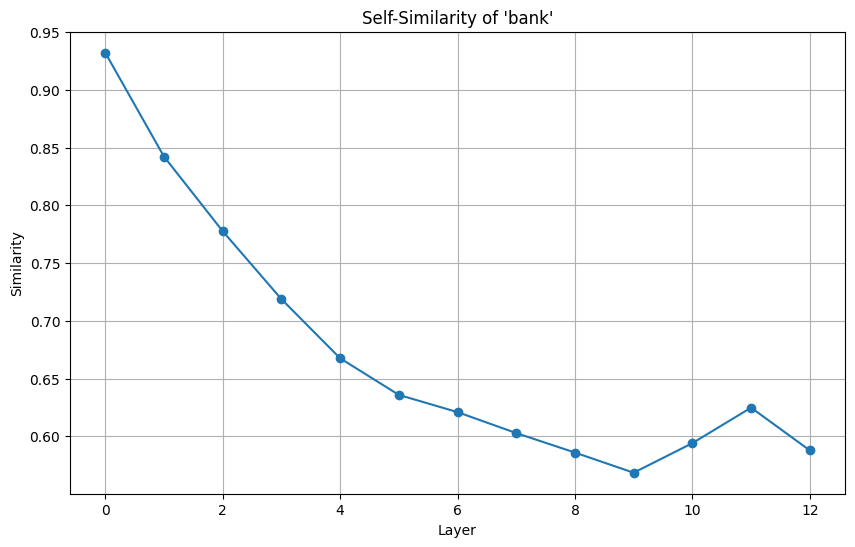

In [6]:
plt.figure(figsize=(10,6))

plt.plot(
    bank_similarity,
    marker="o"
)

plt.title(
    "Self-Similarity of 'bank'"
)

plt.xlabel("Layer")
plt.ylabel("Similarity")

plt.grid(True)

plt.show()

cell 7 - Compute Layer-wise MEV

In [7]:
bank_mev = []

num_layers = len(
    all_embeddings[0]
)

for layer_idx in range(
    num_layers
):

    layer_vectors = []

    for sentence_idx in range(
        len(all_embeddings)
    ):

        layer_vectors.append(
            all_embeddings[sentence_idx][layer_idx]
        )

    score = compute_mev(
        layer_vectors
    )

    bank_mev.append(score)

cell 8 - Print Results

In [8]:
for layer, score in enumerate(bank_mev):

    print(
        f"Layer {layer}: {score:.4f}"
    )

Layer 0: 0.1824
Layer 1: 0.1969
Layer 2: 0.2636
Layer 3: 0.2651
Layer 4: 0.2517
Layer 5: 0.2579
Layer 6: 0.2582
Layer 7: 0.2738
Layer 8: 0.2767
Layer 9: 0.2849
Layer 10: 0.2867
Layer 11: 0.2731
Layer 12: 0.2609


cell 9 - Plot

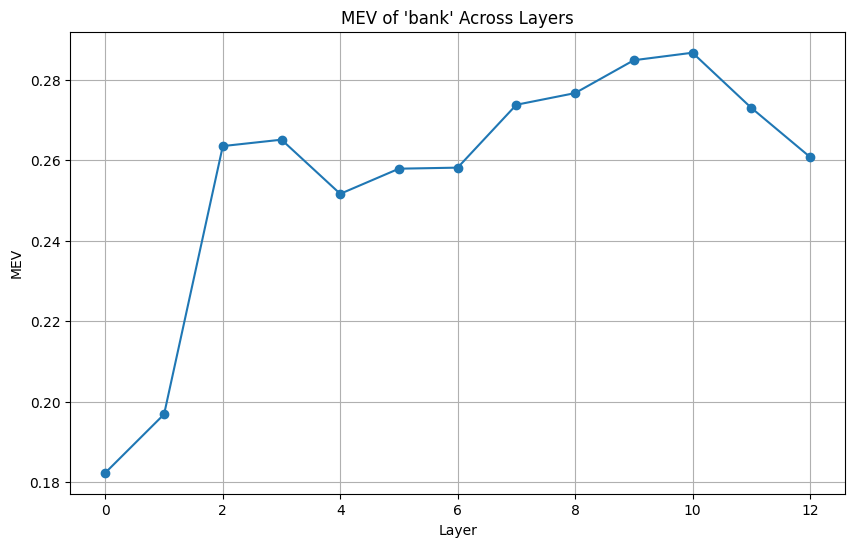

In [9]:
plt.figure(figsize=(10,6))

plt.plot(
    bank_mev,
    marker="o"
)

plt.title(
    "MEV of 'bank' Across Layers"
)

plt.xlabel("Layer")
plt.ylabel("MEV")

plt.grid(True)

plt.show()

cell 10 - plot self sim vs mev

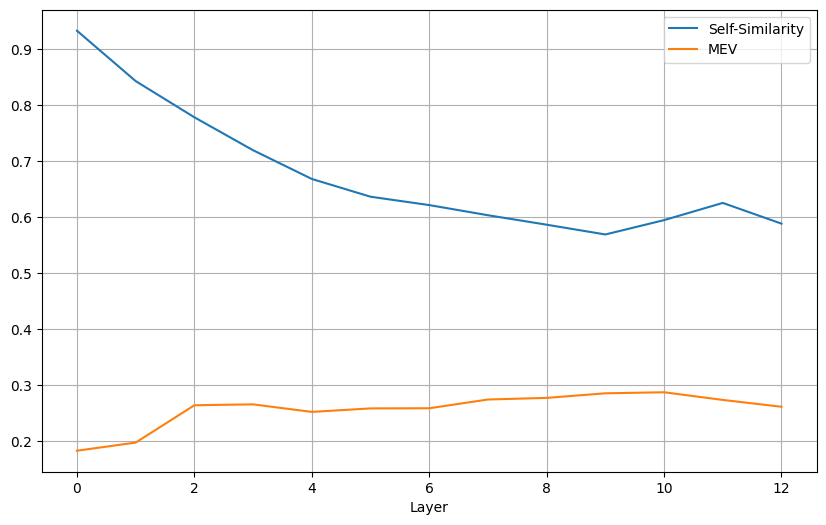

In [10]:
plt.figure(figsize=(10,6))

plt.plot(bank_similarity, label="Self-Similarity")
plt.plot(bank_mev, label="MEV")

plt.xlabel("Layer")
plt.legend()
plt.grid(True)

plt.show()

In lower layers, representations of "bank" exhibit low MEV (~0.18) and high self-similarity (~0.93), consistent with near-static embeddings. In upper layers, self-similarity decreases monotonically, indicating increasing contextualization. Simultaneously, MEV rises to ~0.29 and stabilizes, suggesting that the growing diversity of representations is not isotropic but structured: variance becomes concentrated along a principal axis corresponding to the dominant sense distinction. This pattern is consistent with BERT learning interpretable sense directions rather than dispersing representations uniformly.

Notice that MEV stabilizes around 0.26–0.29 from layers 4–12, rather than continuing to climb. This tells you that the sense-separation structure is largely established in the early-middle layers (2–4) and then maintained, not amplified.

cell 11 - cluster inspection

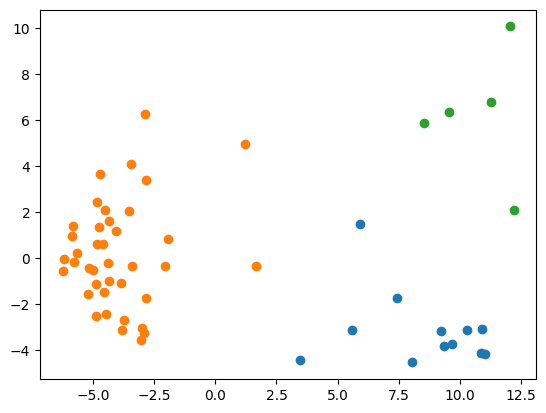

In [ ]:

# Take layer 11 representations (0-indexed), shape (56, 768)
layer_vecs = np.array([all_embeddings[i][11] for i in range(56)])

# Cluster into k senses , k-means starts with random centroids
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(layer_vecs) # fit_predict : learns new centroids_assigns points to clusters

# Visualize in 2D
pca = PCA(n_components=2) # reduce to 2 dimensions instead of 768 for visualization
coords = pca.fit_transform(layer_vecs) # shape becomes (56, 2)

# Plot colored by cluster
for k in range(3):
    mask = labels == k
    plt.scatter(coords[mask, 0], coords[mask, 1], label=f"Sense {k}")

In [12]:
for k in range(3):

    print(f"\n===== CLUSTER {k} =====\n")

    indices = np.where(labels == k)[0]

    for idx in indices[:10]:
        print(bank_contexts[idx])
        print()


===== CLUSTER 0 =====

Grabbing his Winchester from its sheath , Cook prepared to fight from behind the arroyo bank .

Over on the bank , the west bank , a man stood , calling to him .

In the ballroom below , the dark had given way to moonlight coming in through the bank of French windows .

It stood some fifty paces from the edge of the bank .

An officer with a squad of men had been waiting on the bank .

Hillman had ordered him not to leave the far bank .

To his left , the two skiffs dented their sharp bows into the soft bank .

He turned slowly and began to crawl back up the bank toward the rampart .

Watson stumbled down the bank .

Watson supported the man to the edge of the bank and passed the frail figure over the bow of the nearest skiff .


===== CLUSTER 1 =====

It permits the state to take over bank accounts , stocks and other personal property of persons missing for seven years or more .

Dewey Lawrence , a Tyler lawyer representing the Texas Bankers Association , sound

Observation

Clustering the contextual embeddings of "bank" at layer 11 produced three clearly separated groups. Inspection of the contexts reveals that one cluster corresponds to the financial sense of bank, while the remaining clusters correspond to different physical-location senses (river bank, embankment, and related uses). This suggests that BERT organizes contextual representations into semantically meaningful regions of the embedding space without explicit supervision.